In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# 1. DOWNLOAD DATA
# =====================================
df = yf.download("AAPL",start="1980-12-12",end="2026-06-20",auto_adjust=True,progress=False)
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
1980-12-12,0.098207,0.098634,0.098207,0.098207,469033600
1980-12-15,0.093084,0.093510,0.093084,0.093510,175884800
1980-12-16,0.086251,0.086678,0.086251,0.086678,105728000
1980-12-17,0.088386,0.088813,0.088386,0.088386,86441600
1980-12-18,0.090949,0.091376,0.090949,0.090949,73449600
...,...,...,...,...,...
2026-06-12,291.130005,297.140015,289.619995,296.029999,38742100
2026-06-15,296.420013,297.779999,291.700012,294.119995,45732600


In [3]:
# 2. Calculate Daily Returns
df["Return"] = df["Close"].pct_change()

df = df.dropna()

print(df.head())

Price          Close      High       Low      Open     Volume    Return
Ticker          AAPL      AAPL      AAPL      AAPL       AAPL          
Date                                                                   
1980-12-15  0.093084  0.093510  0.093084  0.093510  175884800 -0.052170
1980-12-16  0.086251  0.086678  0.086251  0.086678  105728000 -0.073398
1980-12-17  0.088386  0.088813  0.088386  0.088386   86441600  0.024751
1980-12-18  0.090949  0.091376  0.090949  0.090949   73449600  0.028992
1980-12-19  0.096499  0.096926  0.096499  0.096499   48630400  0.061029


In [4]:
# 2. PREPROCESS
# Scale Returns
data = df["Return"].values.reshape(-1,1)

scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)

In [5]:
# 3. CREATE SEQUENCES
def create_dataset(dataset, time_step=60):

    X = []
    y = []

    for i in range(len(dataset)-time_step):

        X.append(dataset[i:i+time_step,0])
        y.append(dataset[i+time_step,0])

    return np.array(X), np.array(y)

TIME_STEP = 60

X, y = create_dataset(data_scaled,TIME_STEP)

X = X.reshape(X.shape[0],X.shape[1],1)

print(X.shape)

(11410, 60, 1)


In [6]:
# RESHAPE FOR GRU
X = X.reshape(X.shape[0],X.shape[1],1)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (11410, 60, 1)
y Shape: (11410,)


#### Train/Test Split

In [7]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

#### Build GRU

In [8]:
model = Sequential()

model.add(GRU(64,return_sequences=True,input_shape=(TIME_STEP,1)))
model.add(Dropout(0.2))

model.add(GRU(32))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer="adam",loss="mse")

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 60, 64)            12864     
                                                                 
 dropout (Dropout)           (None, 60, 64)            0         
                                                                 
 gru_1 (GRU)                 (None, 32)                9408      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 22305 (87.13 KB)
Trainable params: 22305 (87.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [9]:
# 6. TRAIN MODEL

early_stop = EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True)

history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,batch_size=32,callbacks=[early_stop])

Epoch 1/10

286/286 [==============================] - 28s 71ms/step - loss: 0.0122 - val_loss: 5.1159e-04
Epoch 2/10
286/286 [==============================] - 18s 63ms/step - loss: 0.0045 - val_loss: 8.2896e-04
Epoch 3/10
286/286 [==============================] - 18s 63ms/step - loss: 0.0038 - val_loss: 5.0807e-04
Epoch 4/10
286/286 [==============================] - 18s 63ms/step - loss: 0.0035 - val_loss: 5.9624e-04
Epoch 5/10
286/286 [==============================] - 19s 66ms/step - loss: 0.0032 - val_loss: 7.0516e-04
Epoch 6/10
286/286 [==============================] - 19s 66ms/step - loss: 0.0028 - val_loss: 4.9329e-04
Epoch 7/10
286/286 [==============================] - 19s 67ms/step - loss: 0.0026 - val_loss: 5.1022e-04
Epoch 8/10
286/286 [==============================] - 19s 66ms/step - loss: 0.0023 - val_loss: 5.3805e-04
Epoch 9/10
286/286 [==============================] - 19s 66ms/step - loss: 0.0021 - val_loss: 5.0803e-04
Epoch 10/10
286/286 [========================

In [10]:
# 7. PREDICT

pred = model.predict(X_test)

pred_returns = scaler.inverse_transform(pred)

actual_returns = scaler.inverse_transform(y_test.reshape(-1,1))

72/72 [==============================] - 3s 18ms/step


In [11]:
# 8. EVALUATE

mae = mean_absolute_error(actual_returns,pred_returns)

rmse = np.sqrt(mean_squared_error(actual_returns,pred_returns))

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 0.013064313473466814
RMSE: 0.01883483693901543


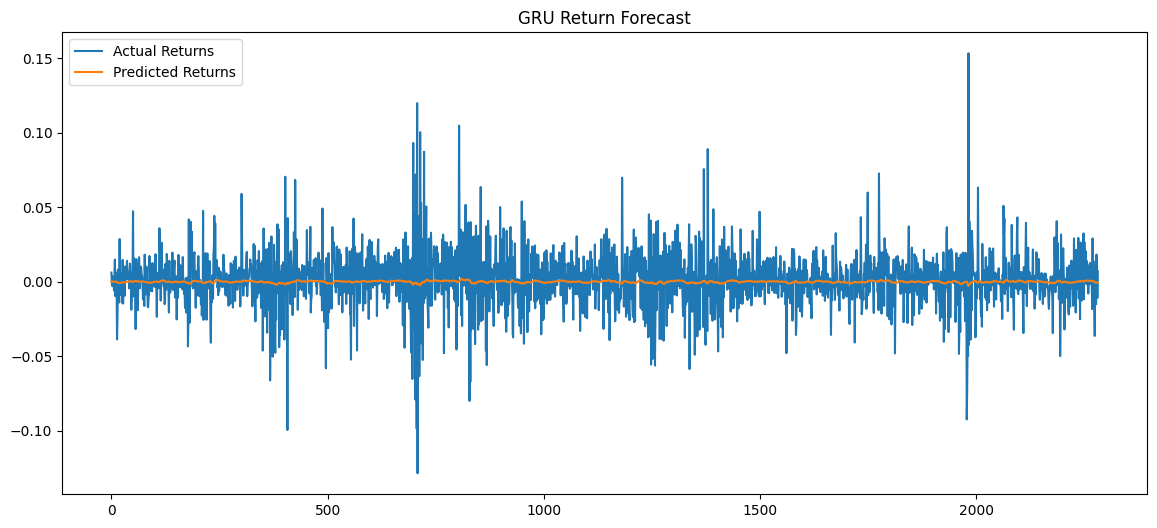

In [12]:
# 9. PLOT Return

plt.figure(figsize=(14,6))

plt.plot(actual_returns,label="Actual Returns")

plt.plot(pred_returns,label="Predicted Returns")

plt.title("GRU Return Forecast")
plt.legend()

plt.show()

In [23]:
# Convert Predicted Returns Back to Prices

In [15]:
last_real_price = df["Close"].iloc[
    len(df) - len(pred_returns) - 1
]

pred_prices = []

current_price = last_real_price

for r in pred_returns.flatten():

    current_price = current_price * (1 + r)

    pred_prices.append(
        current_price
    )

pred_prices = np.array(pred_prices)
pred_prices

array([[35.51392237],
       [35.51569746],
       [35.51618283],
       ...,
       [27.25323088],
       [27.23737332],
       [27.22247686]])

In [22]:
# Compare Actual vs Reconstructed Prices

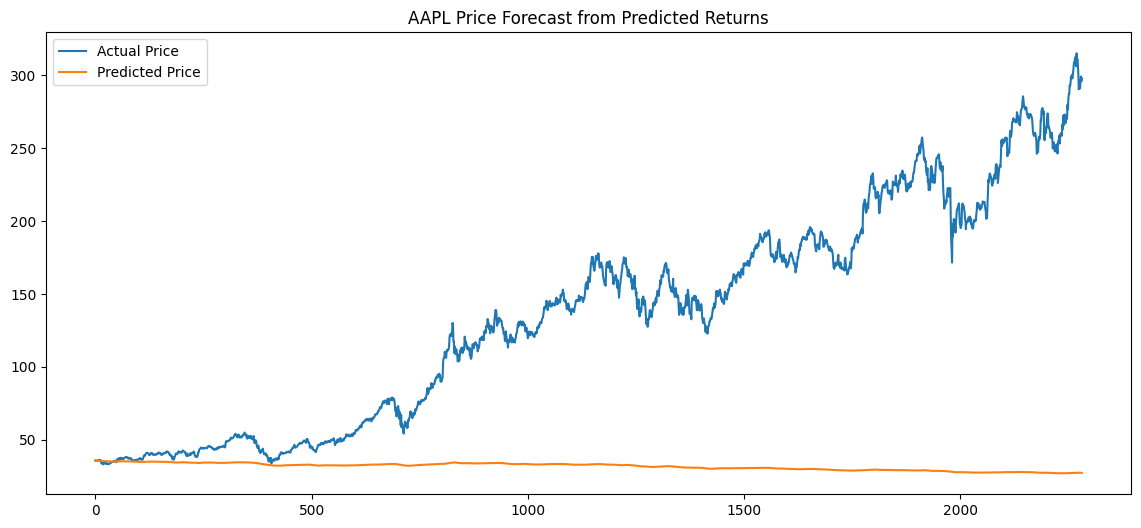

In [16]:
actual_prices = df["Close"].iloc[
    -len(pred_prices):
].values

plt.figure(figsize=(14,6))

plt.plot(
    actual_prices,
    label="Actual Price"
)

plt.plot(
    pred_prices,
    label="Predicted Price"
)

plt.title("AAPL Price Forecast from Predicted Returns")
plt.legend()

plt.show()

In [ ]:
# Forecast Next 7 Returns

In [18]:
# Last 60 return values used as input

last_sequence = data_scaled[-TIME_STEP:]

future_returns = []

current_seq = last_sequence.copy()

for _ in range(7):

    x_input = current_seq.reshape(
        1,
        TIME_STEP,
        1
    )

    next_return = model.predict(
        x_input,
        verbose=0
    )

    future_returns.append(
        next_return[0,0]
    )

    current_seq = np.vstack(
        [
            current_seq[1:],
            next_return
        ]
    )

# Convert back to actual return values

future_returns = scaler.inverse_transform(
    np.array(future_returns).reshape(-1,1)
)

print("Predicted Returns")

for i, r in enumerate(future_returns, start=1):

    print(
        f"Day {i}: {r[0]*100:.3f}%"
    )

Predicted Returns
Day 1: -0.045%
Day 2: -0.039%
Day 3: -0.035%
Day 4: -0.032%
Day 5: -0.030%
Day 6: -0.030%
Day 7: -0.029%


In [ ]:
# Convert Returns to Future Prices

In [19]:
last_price = float(df["Close"].iloc[-1])

future_prices = []

current_price = last_price

for r in future_returns.flatten():

    current_price = current_price * (1 + r)

    future_prices.append(
        current_price
    )

print("\nLast Close Price:", round(last_price,2))

print("\nNext 7 Trading Day Price Forecast")

for i, p in enumerate(future_prices, start=1):

    print(
        f"Day {i}: ${p:.2f}"
    )


Last Close Price: 298.01

Next 7 Trading Day Price Forecast
Day 1: $297.88
Day 2: $297.76
Day 3: $297.66
Day 4: $297.56
Day 5: $297.47
Day 6: $297.38
Day 7: $297.29


C:\Users\vv\AppData\Local\Temp\ipykernel_23428\4037371893.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  last_price = float(df["Close"].iloc[-1])


In [20]:
# Display Results in a Table

In [21]:
forecast_df = pd.DataFrame({

    "Day": range(1,8),

    "Predicted_Return_%":
        future_returns.flatten()*100,

    "Predicted_Price":
        future_prices
})

print(forecast_df)

   Day  Predicted_Return_%  Predicted_Price
0    1           -0.045237       297.875200
1    2           -0.039038       297.758914
2    3           -0.034818       297.655239
3    4           -0.032059       297.559814
4    5           -0.030406       297.469339
5    6           -0.029533       297.381487
6    7           -0.029138       297.294837
